# Importar librerias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Importar datasets

In [2]:
servicios = pd.read_csv('servicios.csv')
proveedores = pd.read_csv('proveedores.csv')
clientes = pd.read_csv('clientes.csv')
calendario = pd.read_csv('calendario.csv')

# Validación de datos a los 4 dataframes se les realizo el mismo proceso

In [3]:
servicios.head()

,servicio_id,fecha_servicio,tipo_servicio,ciudad,cliente,proveedor_id,tiempo_respuesta_min,estado_servicio,costo_servicio
0,SRV012291,2024-03-28 03:28:00,Grúa,Bogotá,Mundial Seguros,3,82.0,Completado,335766
1,SRV013946,2024-06-09 20:45:00,Batería,Bogotá,Banco Davivienda,14,15.0,Completado,151191
2,SRV014899,2024-03-01 23:36:00,Grúa,Barranquilla,Mundial Seguros,146,66.0,Completado,368466
3,SRV010130,2024-02-23 23:49:00,Grúa,Medellín,Liberty Seguros,93,67.0,Completado,289845
4,SRV005568,2024-02-23 00:50:00,Grúa,Bogotá,Avianca,9,65.0,Completado,202441


In [4]:
# Información general del dataframe

servicios.info()

<class 'pandas.DataFrame'>
RangeIndex: 15300 entries, 0 to 15299
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   servicio_id           15300 non-null  str    
 1   fecha_servicio        15300 non-null  str    
 2   tipo_servicio         15300 non-null  str    
 3   ciudad                15300 non-null  str    
 4   cliente               15300 non-null  str    
 5   proveedor_id          15300 non-null  int64  
 6   tiempo_respuesta_min  13928 non-null  float64
 7   estado_servicio       15300 non-null  str    
 8   costo_servicio        15300 non-null  int64  
dtypes: float64(1), int64(2), str(6)
memory usage: 1.1 MB


In [5]:
# Validación de valores nulos en el dataframe

servicios.isnull().sum()

servicio_id                0
fecha_servicio             0
tipo_servicio              0
ciudad                     0
cliente                    0
proveedor_id               0
tiempo_respuesta_min    1372
estado_servicio            0
costo_servicio             0
dtype: int64

In [6]:
# Cantidad de registros repetivos

print(f'La cantidad de registros repetidos es: {servicios.duplicated().sum()}')

La cantidad de registros repetidos es: 285


In [7]:
# Estadistica descriptiva de las columnas dataframe

np.round(servicios.describe(),0)

,proveedor_id,tiempo_respuesta_min,costo_servicio
count,15300.0,13928.0,15300.0
mean,74.0,44.0,192094.0
std,43.0,24.0,86957.0
min,1.0,-20.0,50000.0
25%,38.0,25.0,114123.0
50%,75.0,39.0,188002.0
75%,111.0,62.0,261816.0
max,150.0,147.0,540071.0


In [8]:
# Validación de valores unicos por columnas

servicios.ciudad.unique()

<StringArray>
[      'Bogotá', 'Barranquilla',     'Medellín',         'Cali',
       'BOGOTA',  'Bogota D.C.',      ' Bogotá']
Length: 7, dtype: str

<Axes: >

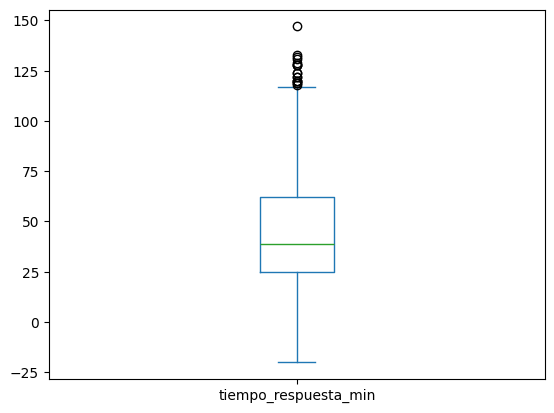

In [9]:
# representación visual de outliers

servicios.tiempo_respuesta_min.plot(kind='box')

# Limpieza de Datos

* Tratamiento de outliers negativos
* Formateo de fechas de STR a datetime
* Eliminar registros duplicados
* Manejo de valores NULL
* Homologación de categorias

In [10]:
# Copia de dataframe originales

servicios_limpio = servicios.copy()
calendario_limpio = calendario.copy()

In [11]:

servicios_limpio = servicios_limpio.query('tiempo_respuesta_min > 0') # Tratamiento de Outlierns negativos

servicios_limpio['fecha_servicio'] = pd.to_datetime(servicios_limpio['fecha_servicio']) # Formatear la fecha de str a datetime

servicios_limpio = servicios_limpio.drop_duplicates() # Borrar valores duplicados

servicios_limpio['tiempo_respuesta_min'] = servicios_limpio['tiempo_respuesta_min'].fillna(servicios_limpio['tiempo_respuesta_min'].mean()) # Llenando los valores nulos con un promedio de tiempos de respuesta

servicios_limpio['ciudad'] = servicios_limpio['ciudad'].map({' Bogotá':'Bogotá',
                                                'BOGOTA':'Bogotá',
                                                'Bogota D.C.':'Bogotá',
                                                'Bogotá':'Bogotá',
                                                'Barranquilla':'Barranquilla',
                                                'Medellín':'Medellín',
                                                'Cali':'Cali'}) # Homologación de ciudades

calendario_limpio['fecha'] = pd.to_datetime(calendario_limpio['fecha']) # Formatear la fecha de str a datetime


In [12]:
calendario_limpio.info()

<class 'pandas.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   fecha       731 non-null    datetime64[us]
 1   mes         731 non-null    str           
 2   año         731 non-null    int64         
 3   es_festivo  731 non-null    str           
dtypes: datetime64[us](1), int64(1), str(2)
memory usage: 23.0 KB
